In [8]:
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [9]:
x, y = make_blobs(
    n_features=2,
    n_samples=2000, 
    random_state=42,
    centers=4)

<Axes: >

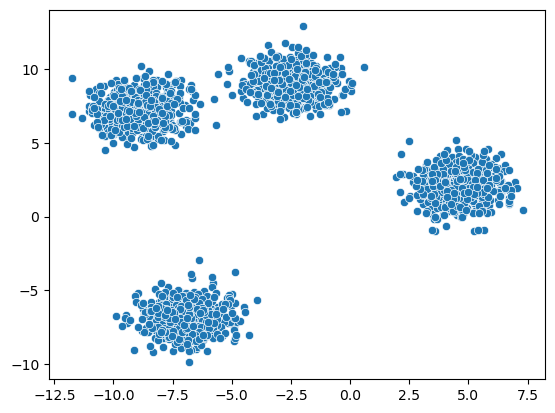

In [10]:
# visualization
sns.scatterplot(x= x[:, 0], y =x[:,1])

<Axes: >

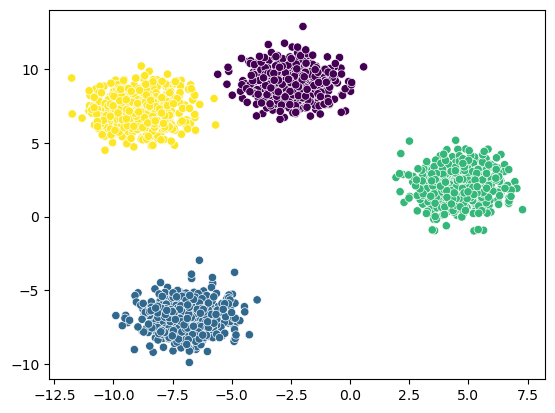

In [12]:
# Implementing the k_means clustering
KM = KMeans( n_clusters=4, random_state=42)
labels = KM.fit_predict(x)
sns.scatterplot(x= x[:, 0], y =x[:,1], c = labels)

# HOW TO CHOOSE K VALUE, - ELBOW METHOD, SILVET METHOD

<Axes: >

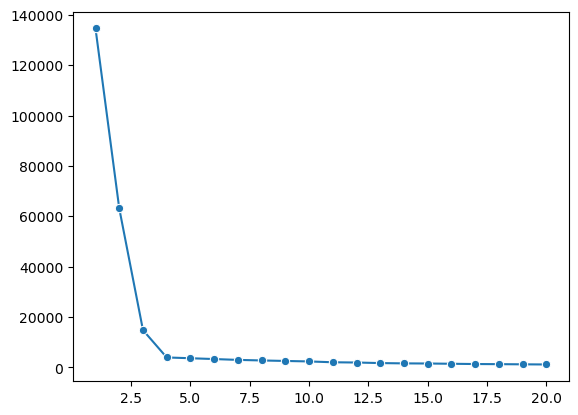

In [20]:
# ELBLOW METHOD
# Manuel Method
#wscc = []
for k in range (1, 21):
    KME = KMeans(n_clusters=k, random_state=42)
    KME.fit_predict(x)
   # wscc.append(KME.inertia_)
# Now we have to plot it against k
sns.lineplot(x=range(1,21), y = wscc, marker="o")

In [21]:
# Automatic Method to get the best value of k 
!pip install kneed

In [22]:
from kneed import KneeLocator
knee = KneeLocator(range(1,21), wscc, curve = "convex", direction = "decreasing")
print ("The best value of Knee is:", knee.elbow)

The best value of Knee is: 4


# Silhouette Score


<Axes: >

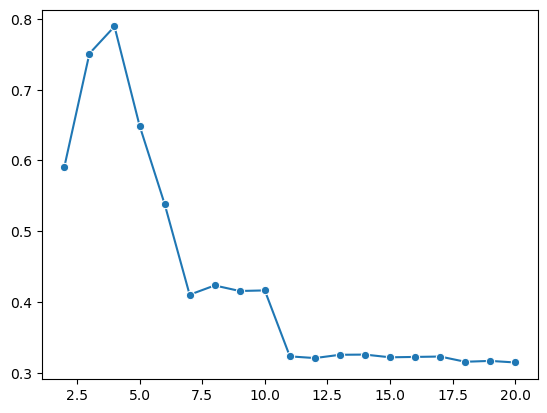

In [27]:
from sklearn.metrics import silhouette_score
ss = []
for k in range(2, 21):    # we always start the silhouette_score with 2
    KME_S = KMeans(n_clusters=k, random_state=42)
    label = KME_S.fit_predict(x)
    ss.append(silhouette_score(x,label))
# now we create a plot for K and silhouette score
sns.lineplot(x=range(2,21), y = ss, marker="o")

In [30]:
# Hierarchical Clusteringi
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [32]:
iris = load_iris()
x = iris.data
y = iris.target
# scaling
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

<Axes: >

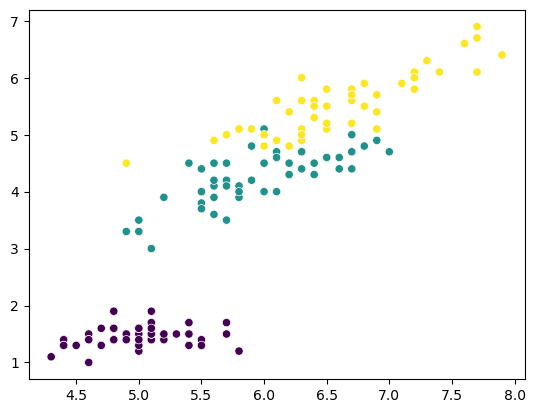

In [33]:
# viualization
sns.scatterplot(x=x[:,0], y = x[:,2], c =y)

Text(0.5, 1.0, 'Dendogram for Heirarchical Structure')

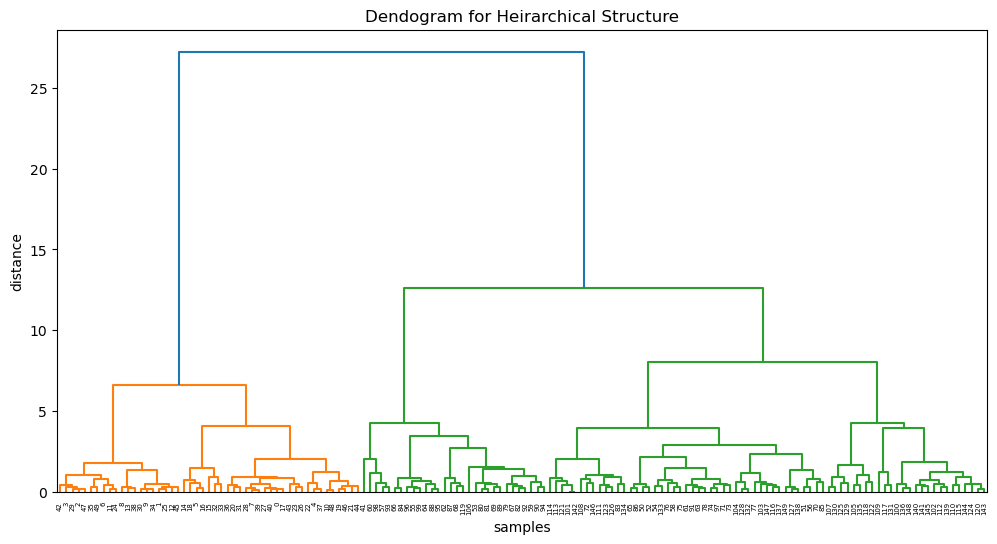

In [35]:
from scipy.cluster.hierarchy import linkage, dendrogram
z = linkage(x_scaled, method = "ward") # for dendrogram metrix
plt.figure(figsize=(12,6))
dendrogram(z)
plt.xlabel("samples")
plt.ylabel("distance")
plt.title("Dendogram for Heirarchical Structure")

<Axes: >

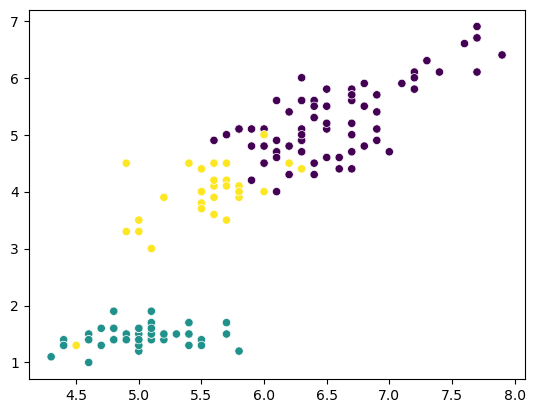

In [37]:
# clustering
from sklearn.cluster import AgglomerativeClustering
ag = AgglomerativeClustering(n_clusters=3)
labels = ag.fit_predict(x_scaled)
sns.scatterplot(x=x[:,0], y = x[:,2], c =labels)